=== DATA SETUP ===
Loaded lifted states shape: (1000, 38)
Total time steps: 1000 | Total lifted dimensions: 38

=== KOOPMAN TRAINING (RIDGE EDMD) ===
Koopman operator matrix K shape: (38, 38)
Training 1-Step RMSE: 0.183438

=== LIVE INFERENCE DEMO ===
Input Live Vector Shape : (1, 38)
Predicted Next Step Shape: (1, 38)
--------------------------------------------------



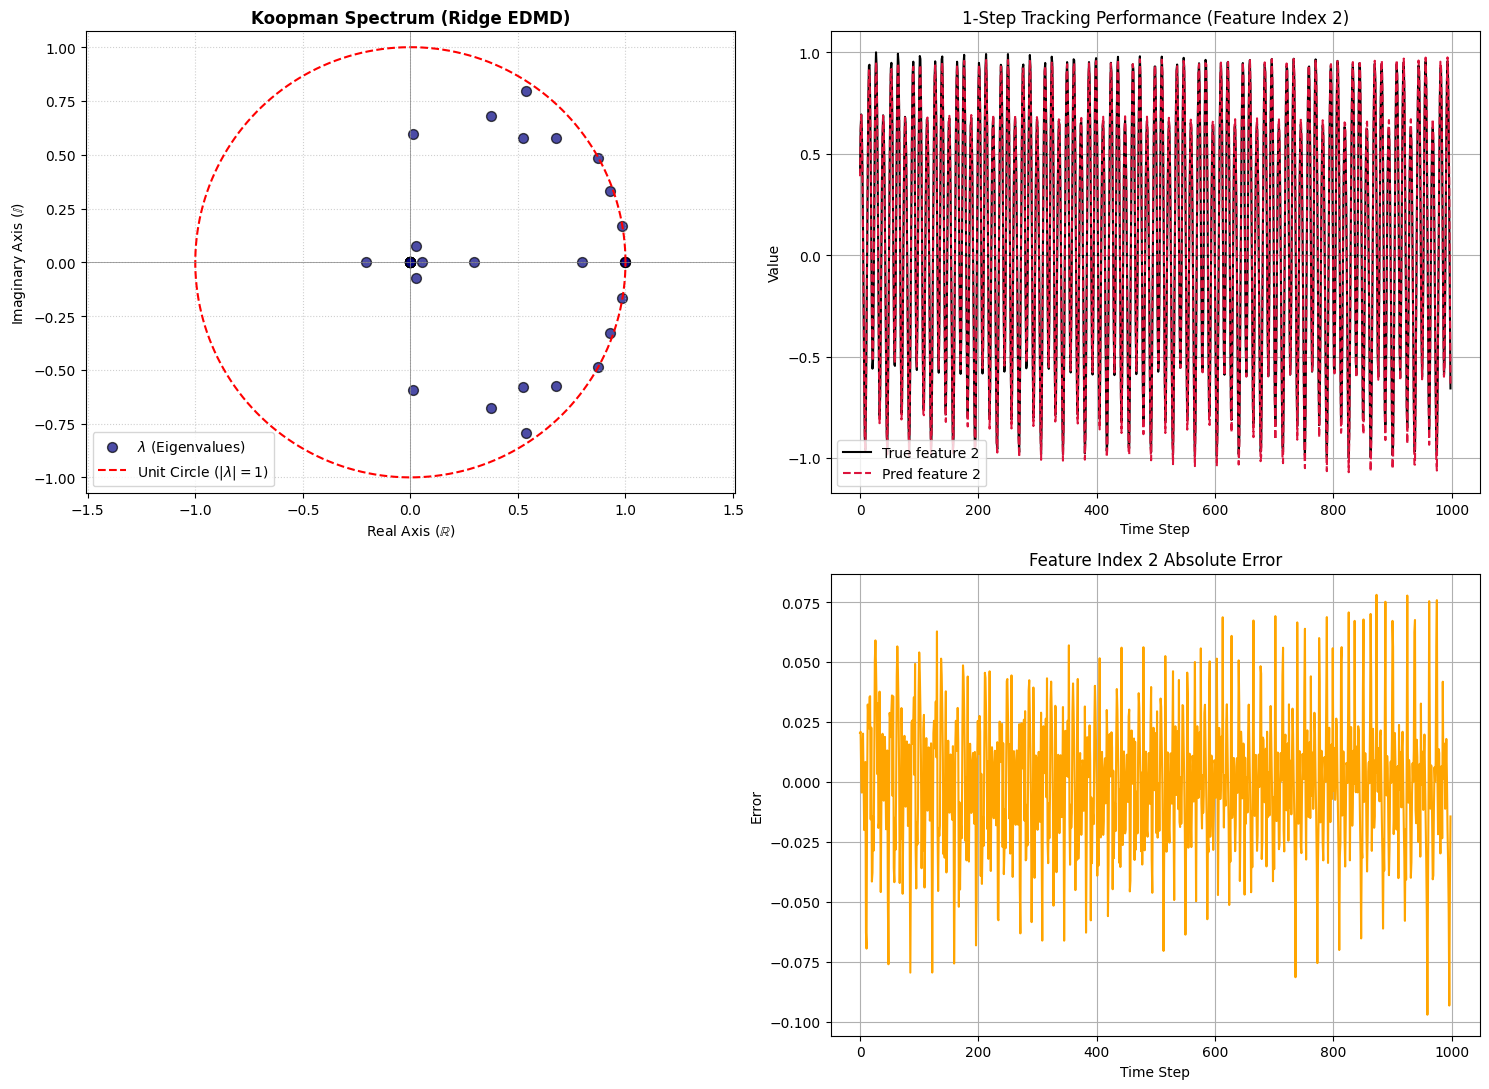

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# ==============================================================================
# 1. DATA LOADING & PREPARATION (TRAINING PHASE)
# ==============================================================================
try:
    df = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find 'lifted_orbit_data.csv'. Please make sure the file is "
        "in your current VS Code working directory."
    )

Z = df.values  # These are your 'lifted' dictionary states \psi(x)
n_samples, n_dim = Z.shape

# Shift data to align Before (Z1 at time k) and After (Z2 at time k+1)
Z1 = Z[:-1]
Z2 = Z[1:]

print(f"=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples} | Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. TRAIN KOOPMAN OPERATOR (RIDGE EDMD FOR OPTIMAL 1-STEP MAPPING)
# ==============================================================================
# alpha=1e-4 adds a small penalty to keep the weights of your 38 features stable
# and handles any high correlations between your gravitational harmonic terms.
model = Ridge(alpha=1e-4, fit_intercept=False)
model.fit(Z1, Z2)

# Extract the Koopman Operator matrix K
# Sklearn returns coefficients shaped as (n_dim, n_dim), ready for row math
K = model.coef_

print(f"=== KOOPMAN TRAINING (RIDGE EDMD) ===")
print(f"Koopman operator matrix K shape: {K.shape}")


# ==============================================================================
# 3. EVALUATE 1-STEP ACCURACY ON TRAINING DATA
# ==============================================================================
# Predict Z2 using our learned K matrix
Z2_pred = Z1 @ K.T

# Calculate Error Metrics
error = Z2 - Z2_pred
error_norm = np.linalg.norm(error, axis=1)
rmse = np.sqrt(np.mean(error**2))

print(f"Training 1-Step RMSE: {rmse:.6f}\n")


# ==============================================================================
# 4. LIVE INFERENCE PHASE (PREDICTING NEXT STEP FROM A 1x38 VECTOR)
# ==============================================================================
print(f"=== LIVE INFERENCE DEMO ===")

# Imagine this is a brand-new, unseen 1x38 vector loaded at a later time
# It must be structured as a 2D array with shape (1, 38)
sample_live_vector = Z1[0:1, :]  # Taking the first row of Z1 as an example input

# Predict the state at t + delta_t
# Formula: z_{k+1} = z_k @ K.T
next_step_prediction = sample_live_vector @ K.T

print(f"Input Live Vector Shape : {sample_live_vector.shape}")
print(f"Predicted Next Step Shape: {next_step_prediction.shape}")
print("-" * 50 + "\n")


# ==============================================================================
# 5. DIAGNOSTIC DASHBOARD VISUALIZATION
# ==============================================================================
# Extract Eigenvalues for analysis
eigvals, _ = np.linalg.eig(K)

plt.figure(figsize=(15, 11))

# Plot A: The Koopman Spectrum
plt.subplot(2, 2, 1)
plt.scatter(eigvals.real, eigvals.imag, color='navy', alpha=0.7, edgecolors='k', s=50, label='$\lambda$ (Eigenvalues)')
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=1.5, label='Unit Circle ($|\lambda|=1$)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("Koopman Spectrum (Ridge EDMD)", fontsize=12, fontweight='bold')
plt.xlabel("Real Axis ($\mathbb{R}$)")
plt.ylabel("Imaginary Axis ($\mathbb{I}$)")
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')

# Plot B: Comparison of predicted and true feature (Index 2)
plt.subplot(2, 2, 2)
plt.plot(Z2[:, 2], label="True feature 2", color='black')
plt.plot(Z2_pred[:, 2], '--', label="Pred feature 2", color='crimson')
plt.title("1-Step Tracking Performance (Feature Index 2)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)


# Plot D: Feature 2 Specific Prediction Error
plt.subplot(2, 2, 4)
feature_error = Z2[:, 2] - Z2_pred[:, 2]
plt.plot(feature_error, color='orange')
plt.title("Feature Index 2 Absolute Error")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()

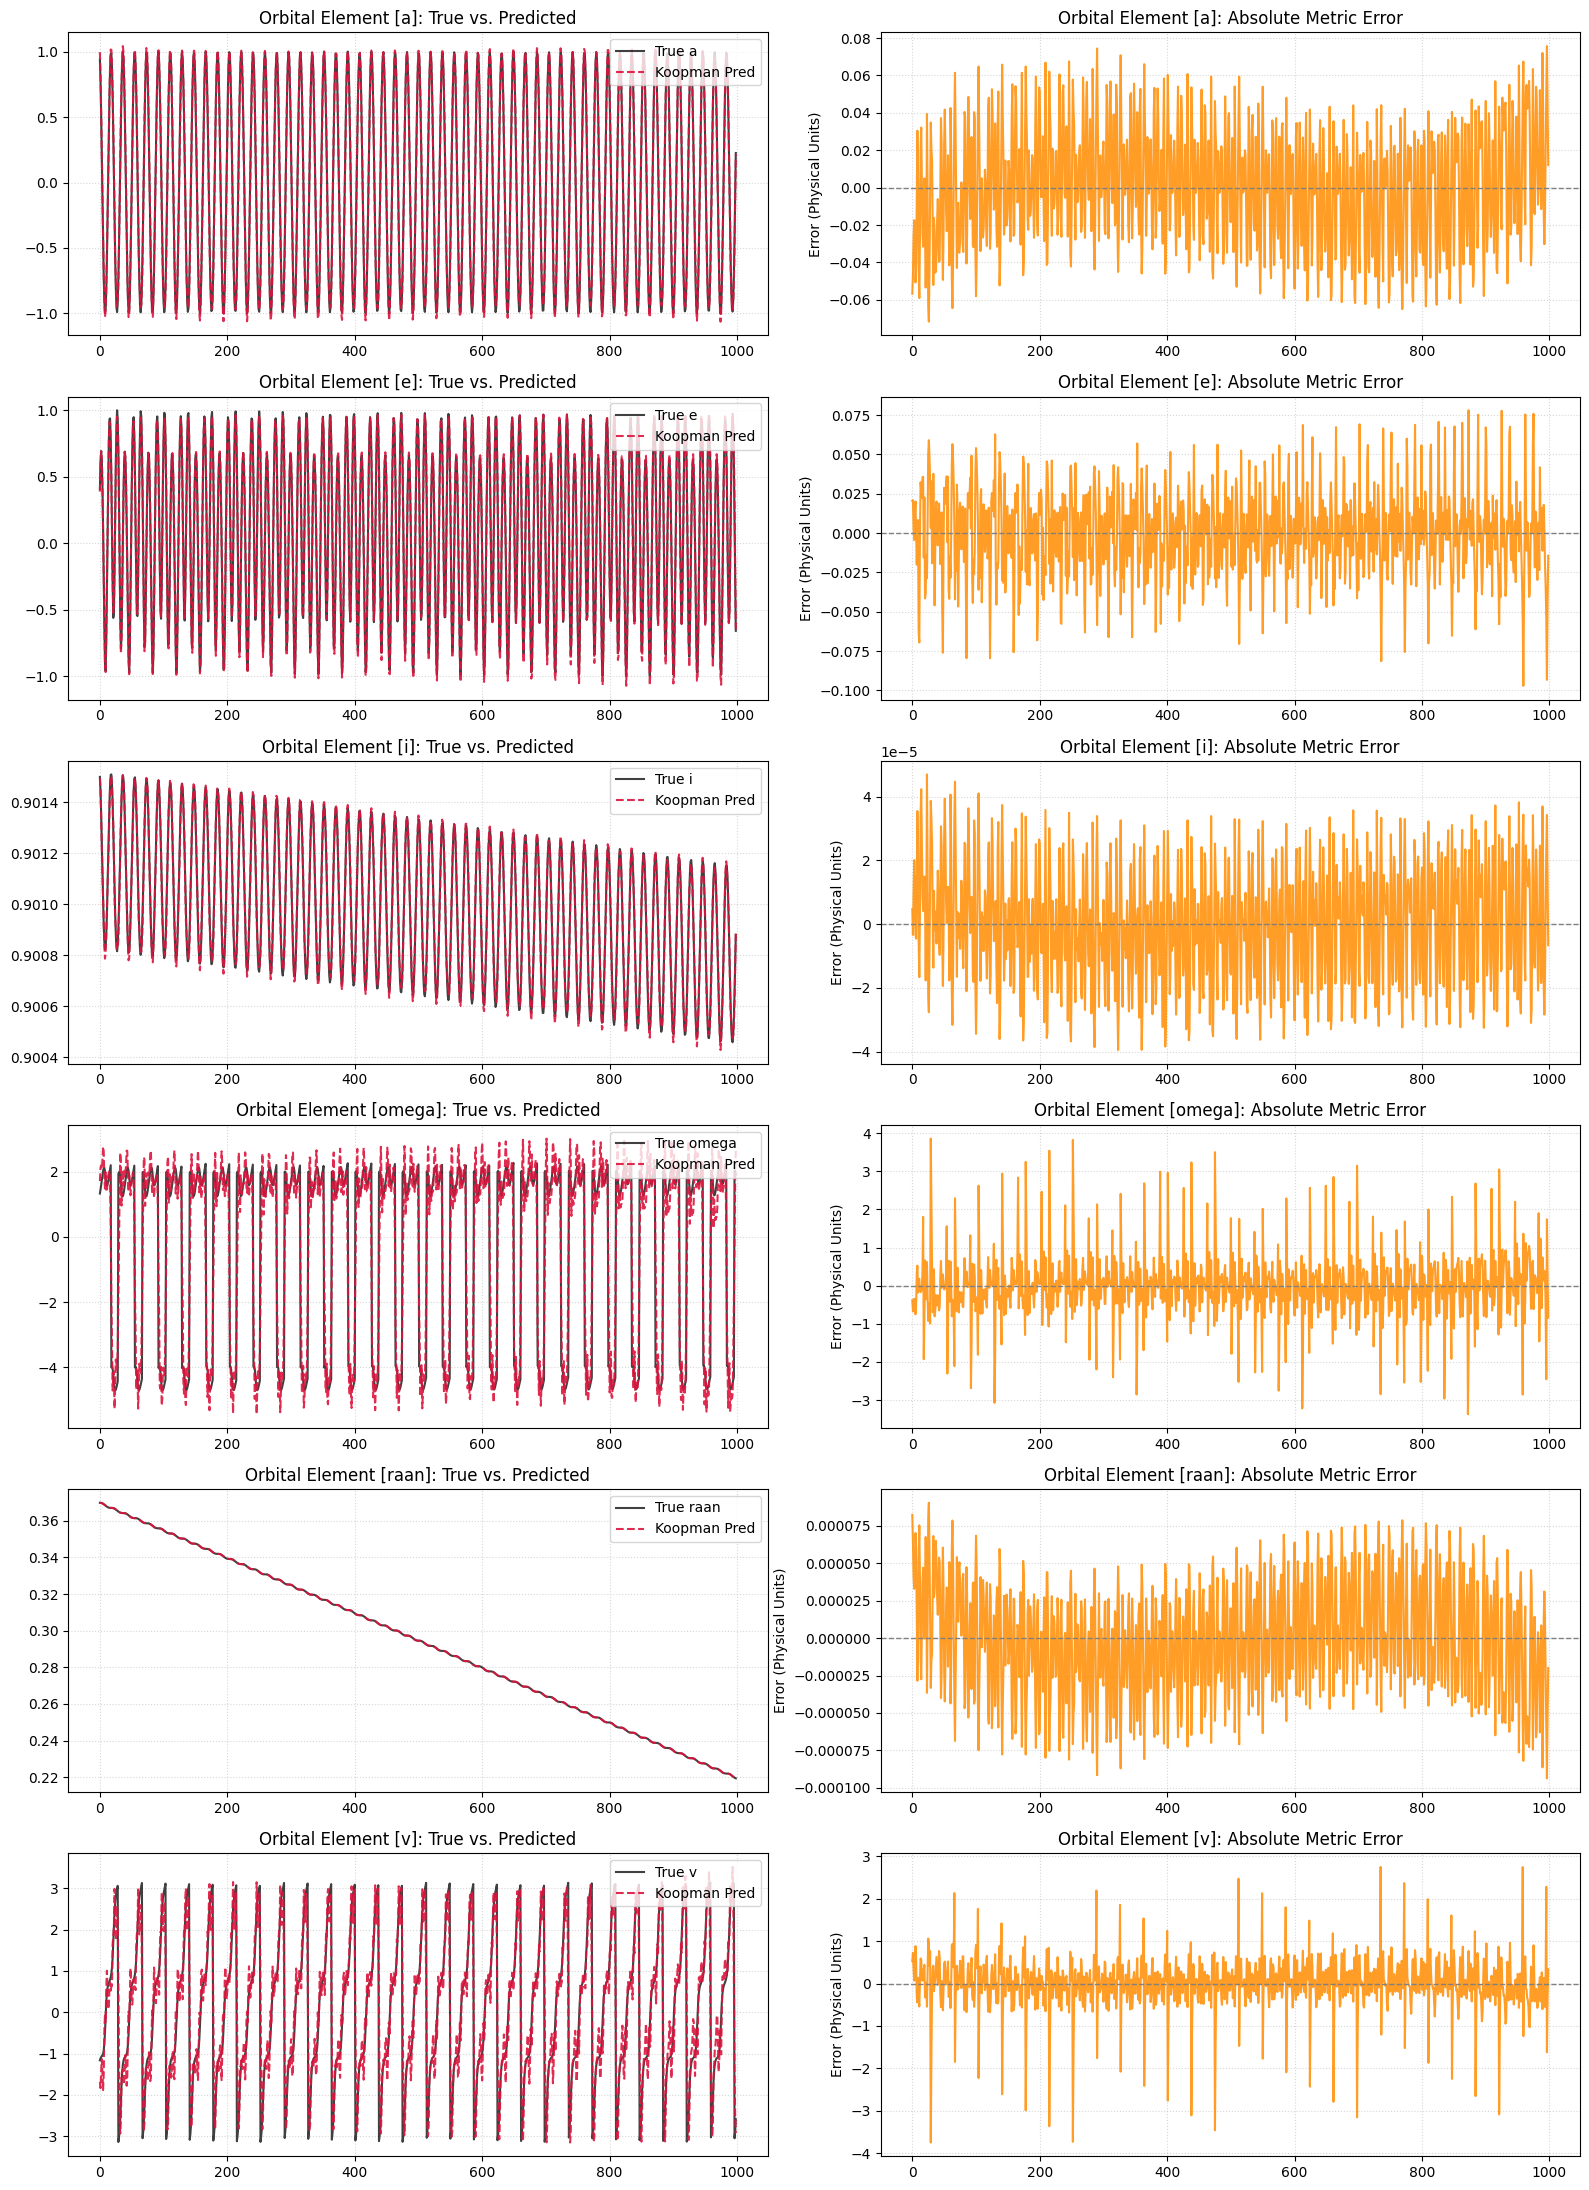

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# ==============================================================================
# 1. LOAD ONLY LIFTED DATA
# ==============================================================================
try:
    df_lifted = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError:
    raise FileNotFoundError("Could not find 'lifted_orbit_data.csv' in your working directory.")

# Define the core 6 orbital features we want to analyze
raw_features = ['a', 'e', 'i', 'omega', 'raan', 'v']

# Extract the true un-shifted matching ground truth for step k+1 directly from the file
df_true_raw = df_lifted[raw_features].iloc[1:].reset_index(drop=True)

# Calculate the min and max bounds for 'a' and 'e' directly from the data 
# to recreate the inverse MinMaxScaler mathematically without loading raw data
a_min, a_max = df_lifted['a'].min(), df_lifted['a'].max()
e_min, e_max = df_lifted['e'].min(), df_lifted['e'].max()


# ==============================================================================
# 2. KOOPMAN TRAINING & LIFTED PREDICTION
# ==============================================================================
Z = df_lifted.values
Z1 = Z[:-1]  # Lifted state at time step k
Z2 = Z[1:]   # True lifted state at time step k+1

# Train Ridge EDMD for 1-step prediction
model = Ridge(alpha=1e-4, fit_intercept=False)
model.fit(Z1, Z2)
K = model.coef_

# Generate 1-step predictions inside the lifted space
Z2_pred_lifted = Z1 @ K.T
df_pred_lifted = pd.DataFrame(Z2_pred_lifted, columns=df_lifted.columns)


# ==============================================================================
# 3. SELF-CONTAINED INVERSE CONVERSION (NO RAW FILE LOADED)
# ==============================================================================
df_pred_raw = pd.DataFrame(index=df_true_raw.index, columns=raw_features)

# Reverse the MinMaxScaler(-1, 1) formula for 'a' mathematically:
# X_original = (((X_scaled - min_range) * (max_val - min_val)) / (max_range - min_range)) + min_val
df_pred_raw['a'] = (((df_pred_lifted['a'] - (-1)) * (a_max - a_min)) / (1 - (-1))) + a_min

# Reverse the MinMaxScaler(-1, 1) formula for 'e' mathematically:
df_pred_raw['e'] = (((df_pred_lifted['e'] - (-1)) * (e_max - e_min)) / (1 - (-1))) + e_min

# Angles require no inverse transform because they were never scaled
for angle in ['i', 'omega', 'raan', 'v']:
    df_pred_raw[angle] = df_pred_lifted[angle]


# ==============================================================================
# 4. PLOT COMPARISONS & ERRORS
# ==============================================================================
fig, axes = plt.subplots(6, 2, figsize=(16, 22))




for idx, col_name in enumerate(raw_features):
    true_physical = df_true_raw[col_name].values
    pred_physical = df_pred_raw[col_name].values
    error_physical = true_physical - pred_physical
    
    # Left Column: Original Units Tracking
    ax_comp = axes[idx, 0]
    ax_comp.plot(true_physical, label=f"True {col_name}", color='black', alpha=0.75)
    ax_comp.plot(pred_physical, '--', label=f"Koopman Pred", color='crimson', alpha=0.9)
    ax_comp.set_title(f"Orbital Element [{col_name}]: True vs. Predicted")
    ax_comp.grid(True, linestyle=':', alpha=0.5)
    ax_comp.legend(loc='upper right')
    
    # Right Column: Pure Physical Residuals
    ax_err = axes[idx, 1]
    ax_err.plot(error_physical, color='darkorange', alpha=0.85)
    ax_err.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax_err.set_title(f"Orbital Element [{col_name}]: Absolute Metric Error")
    ax_err.set_ylabel("Error (Physical Units)")
    ax_err.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()